In [1]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
from configurations import apply_general_styles, set_font_sizes, create_fig
from tracklab import ExperimentReader

apply_general_styles()
set_font_sizes(conf='tight')

In [2]:
from icl.evaluation.theory import _phi
import torch

def prob(snr, L):
    # snr = m #/.* (d) / sigma1.clamp(min=1e-8)
    log_p = (L - 1) * torch.log(_phi(snr).clamp(min=1e-40))
    return torch.exp(log_p)

In [2]:
def _make_text(list,nplaces=2):
    str_list = [f"{x:{nplaces}d}" for x in list]
    return " |".join(str_list)

# Define a function to plot empty squares for mask=1 on an existing axis
def plot_mask_squares(ax, mask,lw=0.5,color='red',alpha=1.0):
    """
    Plots empty squares on the given axis where mask=1.

    Parameters:
    ax : matplotlib.axes.Axes
        The axis on which to plot the squares.
    mask : numpy.ndarray
        A 2D array where squares are drawn for elements equal to 1.
    """
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
                ax.add_patch(rect)
    ax.set_xlim(-0.5, mask.shape[1] - 0.5)
    ax.set_ylim(-0.5, mask.shape[0] - 0.5)
    ax.invert_yaxis()
    ax.set_aspect('equal')

# Get the number that is in a string
def extract_number(s):
    import re
    match = re.search(r'\d+', s)
    if match:
        return int(match.group())
    else:
        return None
    

In [5]:
experiment_name = "full_rank"
reader = ExperimentReader(experiment_name,base_dir="../data")

list_runs = reader.list_runs()

run_id = list_runs[-1]  # Get the most recent run
print(f"Loading run with id: {run_id}")
cfg = reader.load_config(run_id)
print(f"Configuration for the model:")
vocab_size = cfg['model_args']['vocab_size'] 
d_model = cfg['model_args']['d_model']
rank = cfg['model_args']['rank']
seq_len = cfg['model_args']['seq_len']
K = cfg['data_args']['K']
lr = cfg['optim_args']['lr']    
print(f"vocab_size: {vocab_size}, d_model: {d_model}, rank: {rank}, seq_len: {seq_len}, K: {K}, lr: {lr}")

list_artifacts = reader.list_artifacts(run_id)
df = reader.load_metrics(run_id)
# df now has columns: step, metric, value, and possibly others. We want a new dataframe with the different metrics as columns, and the steps as rows. We can use pivot for that.
table = df.pivot(index='step', columns='metric', values='value').reset_index()


unique_metrics = df["metric"].unique().tolist()
# print(unique_metrics)
print(f'\nExtracted Batch:')
batch_file = list_artifacts['file'].iloc[-1]
batch = reader.load_artifact(run_id, batch_file)
print(batch.keys())
for key in batch.keys():
    print(f"{key}: {batch[key].shape}")

Loading run with id: run_006
Configuration for the model:
vocab_size: 32, d_model: 1024, rank: 16, seq_len: 32, K: 16, lr: 1e-05

Extracted Batch:
dict_keys(['sequence', 'trigger_set', 'output_set', 'counts', 'is_trigg', 'mask'])
sequence: torch.Size([100, 33])
trigger_set: torch.Size([100, 16])
output_set: torch.Size([100, 16])
counts: torch.Size([100, 32])
is_trigg: torch.Size([100, 32])
mask: torch.Size([100, 32, 32])


In [6]:
list_artifacts 

,step,file
0,0.0,attn1_step_0.npy
1,0.0,attn2_step_0.npy
2,0.0,scores1_step_0.npy
3,0.0,scores2_step_0.npy
4,0.0,logits_step_0.npy
5,14.0,attn1_step_14.npy
6,14.0,attn2_step_14.npy
7,14.0,scores1_step_14.npy
8,14.0,scores2_step_14.npy
9,14.0,logits_step_14.npy


In [4]:
cfg['extra_args']['n_prints_model']

8

In [4]:
summary = reader.sumarize_runs()

In [9]:
summary.columns

Index(['d_model', 'lr', 'total_steps', 'extra'], dtype='object')

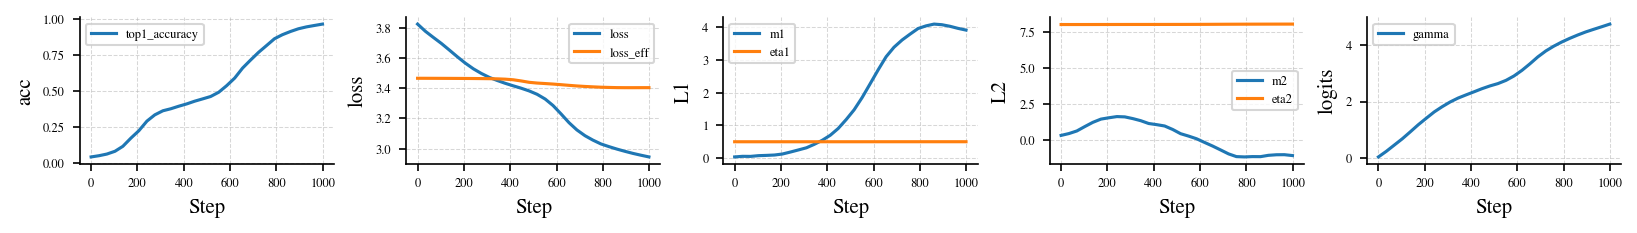

In [32]:
to_plot = {
    'acc' : ['top1_accuracy'],
    'loss' : ['loss','loss_eff'],
    # 'prob' : ['P_L1','P_L2'],
    'L1': ['m1','eta1'],
    'L2' : ['m2','eta2'],

    'logits':['gamma']
}

nrows = len(to_plot)
fig , axes = create_fig(ncols=nrows,size='double',h=.2,w=0.3*nrows)

for i, (title, metrics) in enumerate(to_plot.items()):
    ax = axes[i]
    for metric in metrics:
        if metric in unique_metrics:
            ax.plot(table['step'], table[metric], label=metric)
    ax.set_ylabel(title)
    ax.set_xlabel('Step')
    ax.legend()
    ax.grid(ls='--',alpha=0.5,lw=0.5)
    # ax.set_ylim(bottom=-0.3,top=0.3)
    


In [10]:
from pathlib import Path
import json
import pandas as pd


def flatten(d, parent="", sep="."):
    out = {}
    for k, v in d.items():
        key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            out.update(flatten(v, key, sep))
        else:
            out[key] = v
    return out


def summarize_runs(config_paths):
    rows = []

    for path in config_paths:
        with open(path) as f:
            cfg = json.load(f)

        row = flatten(cfg)
        row["run_id"] = Path(path).stem
        rows.append(row)

    df = pd.DataFrame(rows)#.set_index("run_id")

    # keep only parameters that vary
    varying = df.nunique(dropna=False) > 1
    return df.loc[:, varying]

In [20]:
rows = []
for run_id in list_runs:
    cfg = reader.load_config(run_id)
    # print(f"Run ID: {run_id}")
    row = flatten(cfg)
    row["run_id"] = run_id
    rows.append(row)

df = pd.DataFrame(rows)#.set_index("run_id")
# keep only parameters that vary
varying = df.nunique(dropna=False) > 1
df_varying = df.loc[:, varying]
# Change names of columns to keep only the last part after the last k dots for k=2
k = 1
df_varying.columns = [ ".".join(col.rsplit(".", k)[-k:]) for col in df_varying.columns ]
# Set run_id as index
df_varying = df_varying.set_index("run_id")

df_varying

,d_model,lr,total_steps,extra
run_id,,,,
run_001,2048,0.00002,500,NaN
run_002,1024,0.00002,500,NaN
run_003,1024,0.00001,500,NaN
run_004,1024,0.00001,1000,NaN
run_005,1024,0.00001,1000,
run_006,1024,0.00001,100,hola


In [24]:
df_varying.loc['run_001']

d_model           2048
lr             0.00002
total_steps        500
extra              NaN
Name: run_001, dtype: object

In [76]:
row
# "hola.como.estas.oye.que.estoy.haciendo".rsplit('.', 20)

{'model_args.vocab_size': 32,
 'model_args.seq_len': 32,
 'model_args.d_model': 1024,
 'model_args.rank': 16,
 'model_args.dropout': 0.0,
 'model_args.lin_attn': False,
 'optim_args.lr': 1e-05,
 'optim_args.opt': 'adam',
 'optim_args.momentum': 0.9,
 'optim_args.weight_decay': 0.0,
 'data_args.b_type': 'spiked',
 'data_args.alpha_d': 0.1,
 'data_args.alpha_z': 1.0,
 'data_args.u_type': 'uniform',
 'data_args.beta': 0.0,
 'data_args.fix_trig': True,
 'data_args.trig_type': 'rand',
 'data_args.batch_size': 64,
 'data_args.test_size': 200,
 'data_args.K': 16,
 'extra_args.total_steps': 100,
 'extra_args.n_prints': 30,
 'extra_args.n_prints_model': 8,
 'extra_args.print_scale': 'linear',
 'extra_args.experiment_name': 'full_rank',
 'extra_args.file_name': 'results',
 'extra_args.path': 'induction',
 'extra_args.extra': 'hola',
 'run_id': 'run_006'}

In [54]:
200/np.sqrt(2048)

np.float64(4.419417382415921)

In [9]:
list_artifacts
attn1_files = list_artifacts[list_artifacts['file'].str.contains('scores1')]['file'].to_list()
print(attn1_files)

['scores1_step_0.npy', 'scores1_step_14.npy', 'scores1_step_28.npy', 'scores1_step_42.npy', 'scores1_step_56.npy', 'scores1_step_70.npy', 'scores1_step_84.npy', 'scores1_step_99.npy']


Trigger Set: 	 [11, 29, 22, 26, 3, 14, 30, 7, 4, 21, 15, 5, 31, 20, 17, 16]
Output Set: 	 [19, 7, 14, 1, 14, 12, 26, 15, 8, 16, 17, 3, 13, 5, 25, 18]
InPos: 		  0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |10 |11 |12 |13 |14 |15 |16 |17 |18 |19 |20 |21 |22 |23 |24 |25 |26 |27 |28 |29 |30 |31
Input: 		 20 | 5 | 3 |14 |12 |19 |20 | 5 | 3 |14 |12 | 3 |14 |12 |18 |16 |18 |19 |27 |20 | 5 | 3 |14 |12 |23 |24 | 3 |14 |12 | 1 |18 |16
Is Trigger: 	  1 | 1 | 1 | 1 | 0 | 0 | 1 | 1 | 1 | 1 | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 0 | 0 | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 1 | 1 | 0 | 0 | 0 | 1
Counts: 	  1 | 1 | 1 | 1 | 1 | 1 | 2 | 2 | 2 | 2 | 2 | 3 | 3 | 3 | 1 | 1 | 2 | 2 | 1 | 3 | 3 | 4 | 4 | 4 | 1 | 1 | 5 | 5 | 5 | 1 | 3 | 2


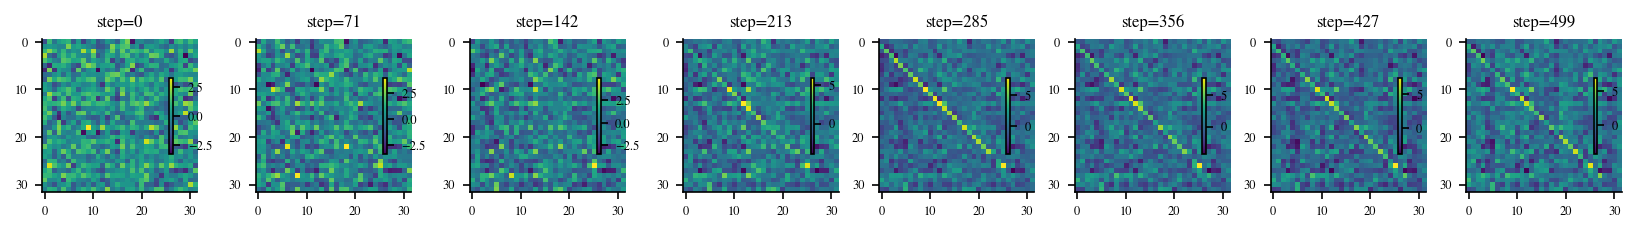

In [95]:
i_batch = 0


l = 32
ncols = len(attn1_files)

is_attn = 'attn' in attn1_files['file'].iloc[0]
masked = 'attn2' in attn1_files['file'].iloc[0] or 'scores2' in attn1_files['file'].iloc[0] 

trigger_set = batch['trigger_set'][i_batch].tolist()
output_set = batch['output_set'][i_batch].tolist()
input = batch['sequence'][i_batch,:-1].tolist()
is_trigg = batch['is_trigg'][i_batch].tolist()
counts = batch['counts'][i_batch].tolist()


if masked:
    mask = np.zeros((len(input), len(input)))
    print(mask.shape)
    for i in range(mask.shape[0]):
        if is_trigg[i] == 1 and counts[i] > 1:
            trig = input[i]
            out = output_set[trigger_set.index(trig)]
            for j in range(i):
                if input[j] == out:
                    mask[i,j] = 1
    mask = mask[:l,:l]


fig , axes = create_fig(ncols=ncols, size='double',h=0.2,w=1.5)

for i , file in enumerate(attn1_files['file']):
    attn = reader.load_artifact(run_id, file)[i_batch][:l,:l]
    
    ax = axes[i]
    # Mask the uper triangle of the score matrix to -inf for scores and to 0 for attn
    # if not is_attn:
        # attn = np.tril(attn)

    im = ax.imshow(attn, aspect='auto', cmap='viridis')
    if masked:
        plot_mask_squares(ax, mask,lw=0.6,alpha=0.7,color='r')

    
    ax.set_title(f'step={extract_number(file[-8:-4])}',fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=-0.18, shrink=0.5)

# fig.suptitle(f"Plot of attention {'probabilities' if is_attn else 'scores'}")

print(f"Trigger Set: \t {trigger_set}")
print(f"Output Set: \t {output_set}")
print(f"InPos: \t\t {_make_text(np.arange(len(input)))}")
print(f"Input: \t\t {_make_text(input)}")
print(f"Is Trigger: \t {_make_text(is_trigg)}")
print(f"Counts: \t {_make_text(counts)}")

torch.Size([100, 32, 32])


/tmp/ipykernel_912300/2967829858.py:21: RuntimeWarning: Mean of empty slice.
  ax.set_title(f"Step = {number}\nB: {data_bulk.mean():.2f} +/- {data_bulk.std():.5f}\n S: {data_spike.mean():.2f} +/- {data_spike.std():.2f}",fontsize=8)
/u/c/cerazova/miniconda3/envs/icl/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/u/c/cerazova/miniconda3/envs/icl/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/u/c/cerazova/miniconda3/envs/icl/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/u/c/cerazova/miniconda3/envs/icl/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


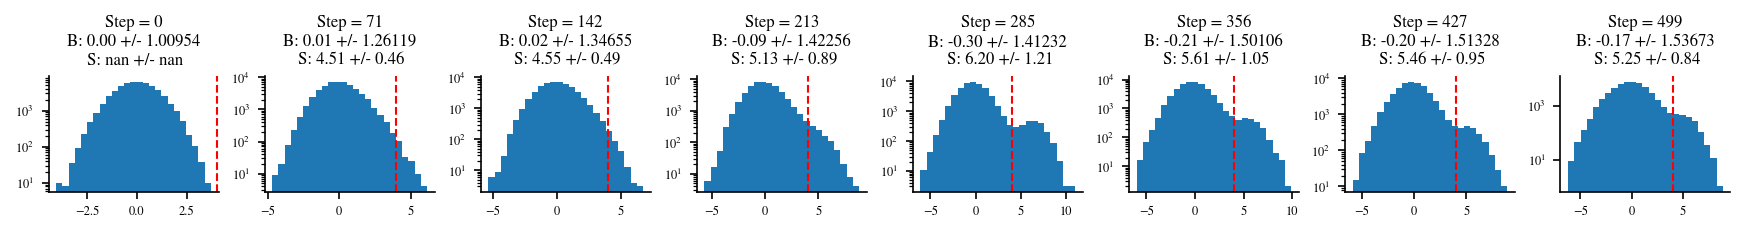

In [ ]:
th = 4
position = 20

mask = batch['mask'].cpu()
print(mask.shape)
fig , axes = create_fig(ncols=ncols, size='double',h=0.2,w=1.6,sharex=False,sharey=False)

for i , file in enumerate(attn1_files['file']):
    number = extract_number(file[-11:])
    matrix = reader.load_artifact(run_id, file)
    # data = matrix[:,position,:position].flatten()
    data =  
    # data = matrix.flatten()


    data_bulk = data[data<th]
    data_spike = data[data>=th]
    ax = axes[i]
    ax.hist(data,bins=25)
    ax.axvline(th, color='r', linestyle='--',lw=1)
    ax.set_title(f"Step = {number}\nB: {data_bulk.mean():.2f} +/- {data_bulk.std():.5f}\n S: {data_spike.mean():.2f} +/- {data_spike.std():.2f}",fontsize=8)
    ax.set_yscale('log')

In [ ]:
list_artifacts
attn1_files = list_artifacts[list_artifacts['file'].str.contains('eigenva')]
print(attn1_files)

Empty DataFrame
Columns: [step, file]
Index: []


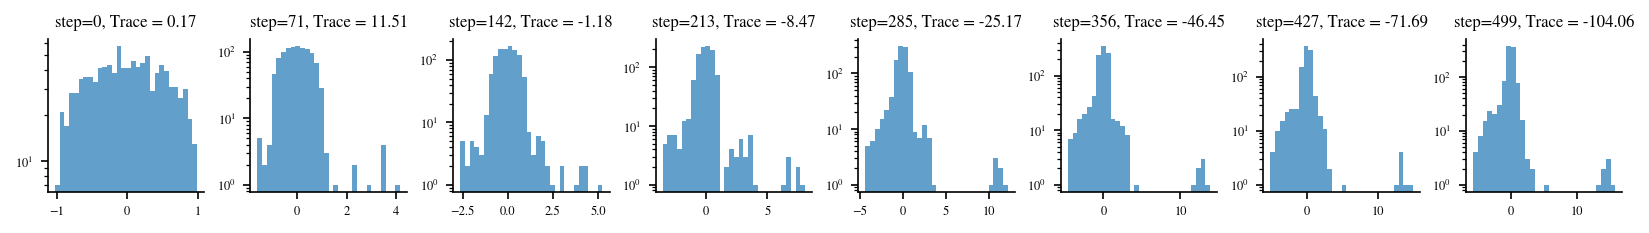

In [87]:

fig , axes = create_fig(ncols=ncols, size='double',h=0.2,w=1.5,sharex=False,sharey=False)

for i , file in enumerate(attn1_files['file']):
    eivals = reader.load_artifact(run_id, file)
    
    ax = axes[i]
    
    # ax.plot(eivals.real, eivals.imag, '.',markersize=1,alpha=0.2)
    ax.hist(eivals.real, bins=30, alpha=0.7, label='Real Part')
    ax.set_title(f'step={extract_number(file[-8:-4])}, Trace = {eivals.sum().real:.2f}',fontsize=8)
    ax.set_yscale('log')